# Arithmetic Operations in Images

This notebook demonstrates four fundamental arithmetic operations applied to images:

| # | Operation | Application |
|---|-----------|-------------|
| 1 | **Addition** | Noise reduction by averaging *k* noisy images |
| 2 | **Subtraction** | Difference between original and LSB-zeroed image |
| 3 | **Multiplication** | Applying shading to a checkerboard |
| 4 | **Division** | Shading correction and binary masking |

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42)
SIZE = 256   # image size in pixels

# Utility: clamp array values to [lo, hi]
def clamp(arr, lo=0, hi=255):
    return np.clip(arr, lo, hi)

# Utility: display a row of images with titles
def show_row(images, titles, cmaps=None, vmins=None, vmaxs=None, suptitle=''):
    n = len(images)
    if cmaps  is None: cmaps  = ['gray'] * n
    if vmins  is None: vmins  = [None]   * n
    if vmaxs  is None: vmaxs  = [None]   * n
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4.5))
    if n == 1: axes = [axes]
    for ax, img, title, cmap, vmin, vmax in zip(axes, images, titles, cmaps, vmins, vmaxs):
        ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=11)
        ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1 · Addition — Noise Reduction by Averaging *k* Images

### Theory

Suppose each observed image $g_i(x,y)$ is a noisy version of the true image $f(x,y)$:

$$g_i(x,y) = f(x,y) + n_i(x,y), \quad n_i \sim \mathcal{N}(0,\,\sigma^2)$$

Because the noise is **zero-mean** and **independent**, averaging $k$ such images gives:

$$\hat{g}(x,y) = \frac{1}{k}\sum_{i=1}^{k} g_i(x,y) \;\xrightarrow{k\to\infty}\; f(x,y)$$

The noise standard deviation in the average drops from $\sigma$ to $\sigma/\sqrt{k}$.

| k | Noise σ_avg |
|---|-------------|
| 1 | 40.0 |
| 4 | 20.0 |
| 16 | 10.0 |
| 64 | 5.0 |

In [9]:
# ── Parameters ───────────────────────────────────────────
k     = 100    # number of noisy images to average
sigma = 100    # noise standard deviation (0-255 scale)

# ── Clean image: smooth sinusoidal gradient ───────────────
x = np.linspace(0, 1, SIZE)
X, Y = np.meshgrid(x, x)
clean = np.sin(np.pi * X) * np.sin(np.pi * Y) * 200 + 28   # float64, [28, 228]

# ── Generate k noisy images and accumulate ────────────────
accumulator  = np.zeros_like(clean)
noisy_sample = None

for i in range(k):
    noisy_i      = clean + np.random.normal(0, sigma, clean.shape)
    accumulator += noisy_i
    if i == 0:
        noisy_sample = noisy_i

averaged = accumulator / k

print(f'Noise σ in one image  : {sigma:.1f}')
print(f'Noise σ after averaging: {sigma / np.sqrt(k):.2f}  (theoretical = σ/√k)')
print(f'Measured σ of residual : {np.std(averaged - clean):.2f}')

Noise σ in one image  : 100.0
Noise σ after averaging: 10.00  (theoretical = σ/√k)
Measured σ of residual : 10.00


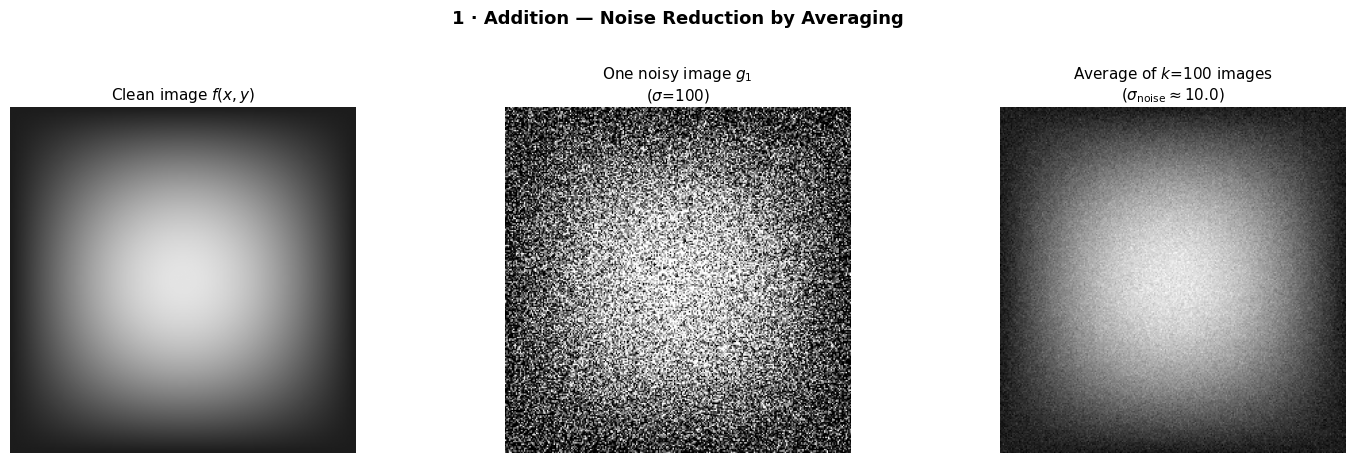

In [10]:
show_row(
    images=[clean, noisy_sample, averaged],
    titles=[
        'Clean image $f(x,y)$',
        f'One noisy image $g_1$\n($\\sigma$={sigma})',
        f'Average of $k$={k} images\n($\\sigma_{{\\mathrm{{noise}}}}\\approx${sigma/np.sqrt(k):.1f})'
    ],
    vmins=[0,0,0], vmaxs=[255,255,255],
    suptitle='1 · Addition — Noise Reduction by Averaging'
)

---
## 2 · Subtraction — LSB Zeroing

### Theory

Each pixel in an 8-bit image has values in $[0, 255]$. Its **least significant bit (LSB)** contributes only $2^0 = 1$ to the pixel value. Setting it to zero uses a bitwise AND:

$$f'(x,y) = f(x,y) \;\mathtt{AND}\; \underbrace{\texttt{11111110}_2}_{= 254_{10} = \texttt{0xFE}_{16}}$$

The difference image:

$$d(x,y) = f(x,y) - f'(x,y) \in \{0, 1\}$$

reveals a **binary map** of where the LSB was set. Scaled by 127 it becomes visible. This operation is relevant in:
- **Steganography**: hiding information in the LSB plane
- **Quantisation analysis**: measuring the effect of bit-depth reduction

In [5]:
# ── Original image: ramp + sinusoidal texture ─────────────
ramp = np.tile(np.linspace(0, 255, SIZE), (SIZE, 1))          # horizontal ramp
Xs, Ys = np.meshgrid(np.linspace(0, 4*np.pi, SIZE),
                     np.linspace(0, 4*np.pi, SIZE))
wave = np.sin(Xs) * np.cos(Ys) * 60
original = clamp(ramp + wave).astype(np.uint8)

# ── Zero the LSB with bitwise AND ────────────────────────
lsb_zeroed = original & np.uint8(0xFE)          # 0xFE = 11111110 in binary

# ── Compute difference (int16 to avoid overflow) ─────────
diff = original.astype(np.int16) - lsb_zeroed.astype(np.int16)
diff_scaled = (np.abs(diff) * 127).astype(np.uint8)   # {0,1} → {0,127}

lsb_fraction = np.mean(diff > 0) * 100
print(f'Pixels with LSB = 1 : {lsb_fraction:.1f}%  (expect ~50% for natural images)')

Pixels with LSB = 1 : 49.9%  (expect ~50% for natural images)


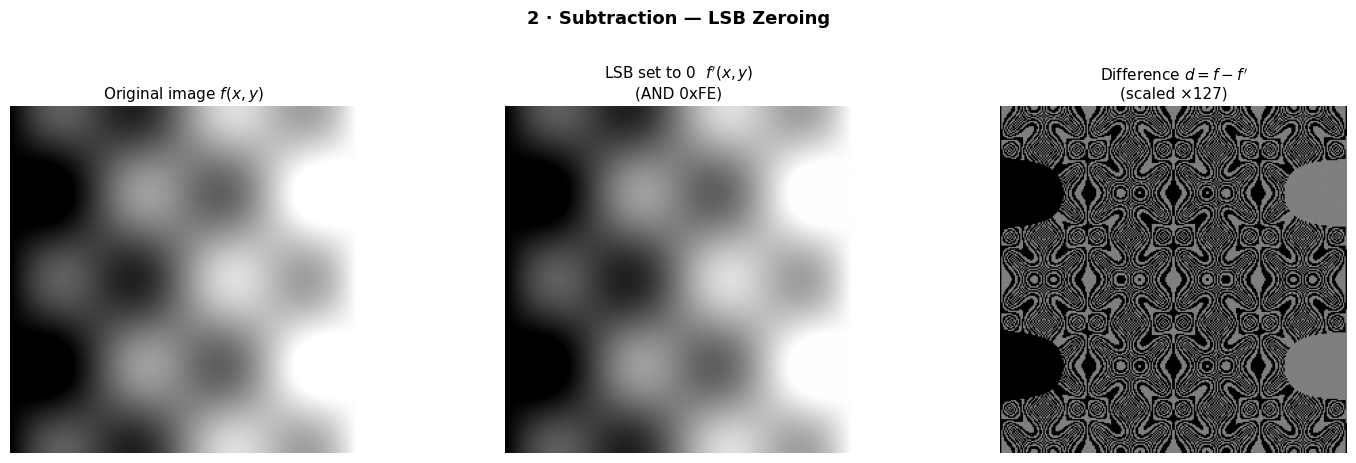

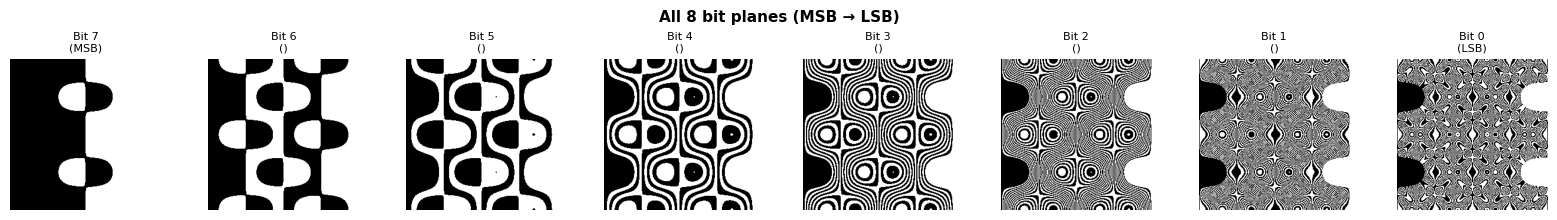

In [6]:
show_row(
    images=[original, lsb_zeroed, diff_scaled],
    titles=[
        'Original image $f(x,y)$',
        'LSB set to 0  $f\'(x,y)$\n(AND 0xFE)',
        'Difference $d = f - f\'$\n(scaled ×127)'
    ],
    vmins=[0,0,0], vmaxs=[255,255,255],
    suptitle='2 · Subtraction — LSB Zeroing'
)

# ── Bit-plane analysis ────────────────────────────────────
fig, axes = plt.subplots(1, 8, figsize=(16, 2.2))
for bit in range(7, -1, -1):
    plane = ((original >> bit) & 1) * 255
    axes[7 - bit].imshow(plane, cmap='gray', vmin=0, vmax=255)
    axes[7 - bit].set_title(f'Bit {bit}\n({"MSB" if bit==7 else "LSB" if bit==0 else ""})',
                             fontsize=8)
    axes[7 - bit].axis('off')
fig.suptitle('All 8 bit planes (MSB → LSB)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3 · Multiplication — Shading Applied to a Checkerboard

### Theory

In real imaging systems, the illumination is rarely uniform. A **shading field** $s(x,y) \in (0, 1]$ modulates the ideal scene $f(x,y)$:

$$g(x,y) = f(x,y) \cdot s(x,y)$$

Here we simulate this by **multiplying** a perfect black-and-white checkerboard by a smooth radial shading field (bright centre, dark edges). This is exactly what cameras see with vignetting or non-uniform lighting.

The shading field used here:

$$s(x,y) = 1 - 0.65\,\frac{(x-c_x)^2+(y-c_y)^2}{c_x^2+c_y^2}$$

In [7]:
# ── Ideal checkerboard (float [0,1]) ─────────────────────
tile = 32
col, row = np.meshgrid(np.arange(SIZE), np.arange(SIZE))
checker_mask = (np.floor(row / tile) + np.floor(col / tile)) % 2
checkerboard = np.where(checker_mask == 0, 220/255, 50/255)   # light / dark

# ── Radial shading field ──────────────────────────────────
cx, cy = SIZE // 2, SIZE // 2
Xg, Yg = np.meshgrid(np.arange(SIZE), np.arange(SIZE))
shading = 1.0 - 0.65 * ((Xg - cx)**2 + (Yg - cy)**2) / (cx**2 + cy**2)
shading = np.clip(shading, 0.1, 1.0)

# ── Apply shading via MULTIPLICATION ─────────────────────
shaded = checkerboard * shading

print(f'Checkerboard pixel range : [{checkerboard.min():.3f}, {checkerboard.max():.3f}]')
print(f'Shading field range      : [{shading.min():.3f}, {shading.max():.3f}]')
print(f'Shaded image range       : [{shaded.min():.3f}, {shaded.max():.3f}]')

Checkerboard pixel range : [0.196, 0.863]
Shading field range      : [0.350, 1.000]
Shaded image range       : [0.070, 0.863]


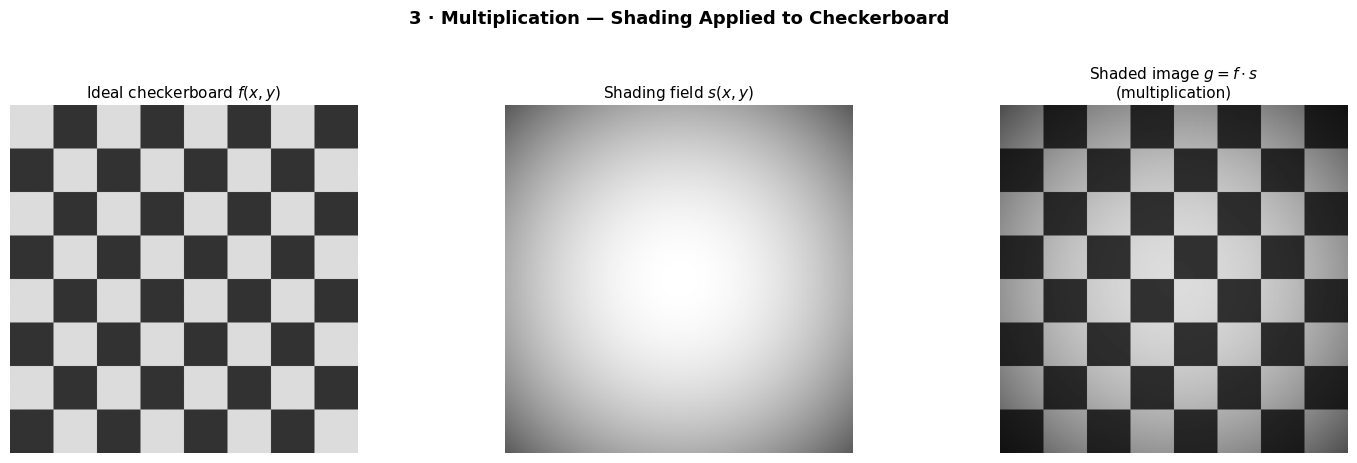

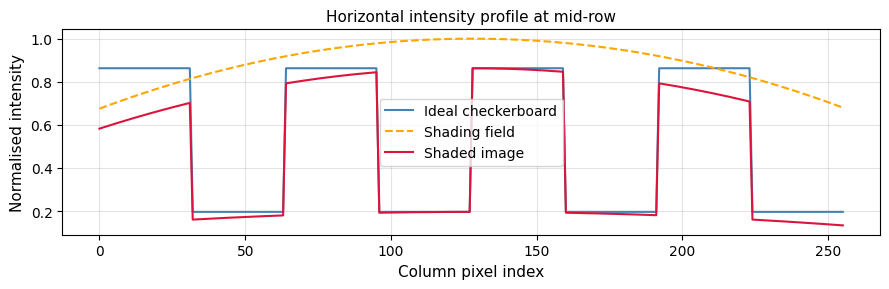

In [8]:
show_row(
    images=[checkerboard, shading, shaded],
    titles=[
        'Ideal checkerboard $f(x,y)$',
        'Shading field $s(x,y)$',
        'Shaded image $g = f \\cdot s$\n(multiplication)'
    ],
    vmins=[0,0,0], vmaxs=[1,1,1],
    suptitle='3 · Multiplication — Shading Applied to Checkerboard'
)

# ── Intensity profile along horizontal midline ────────────
mid = SIZE // 2
plt.figure(figsize=(9, 3))
plt.plot(checkerboard[mid, :], label='Ideal checkerboard', lw=1.5, color='steelblue')
plt.plot(shading[mid, :],      label='Shading field',      lw=1.5, color='orange', linestyle='--')
plt.plot(shaded[mid, :],       label='Shaded image',       lw=1.5, color='crimson')
plt.xlabel('Column pixel index', fontsize=11)
plt.ylabel('Normalised intensity', fontsize=11)
plt.title('Horizontal intensity profile at mid-row', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

---
## 4 · Division — Shading Correction & Masking

### Theory

**Shading correction** (flat-field correction):

$$\hat{f}(x,y) = \frac{g(x,y)}{s(x,y)}$$

If the shading field $s$ is known, dividing the degraded image $g$ by $s$ recovers the true image $f$. This technique is standard in **microscopy**, **astronomy**, and **document scanning**.

**Binary masking via division**:

$$\text{masked}(x,y) = \begin{cases} g(x,y) / M(x,y) & M(x,y) = 1 \\ 0 & M(x,y) = 0 \end{cases}$$

Dividing by a binary mask $M \in \{0,1\}$ is equivalent to isolating a region of interest and zeroing everything outside it.

In [9]:
# ── (a) Shading correction via DIVISION ───────────────────
corrected = np.where(shading > 0, shaded / shading, 0)
corrected  = np.clip(corrected, 0, 1)

residual_error = np.mean(np.abs(corrected - checkerboard))
print(f'Mean absolute error after correction: {residual_error:.6f}  (should be ~0)')

# ── (b) Circular binary mask ──────────────────────────────
r_mask = SIZE // 3
mask   = ((Xg - cx)**2 + (Yg - cy)**2 <= r_mask**2).astype(np.float64)

masked = np.where(mask > 0, shaded / mask, 0)
masked = np.clip(masked, 0, 1)

print(f'Mask covers {mask.mean()*100:.1f}% of image pixels')

Mean absolute error after correction: 0.000000  (should be ~0)
Mask covers 34.6% of image pixels


C:\Users\L03508435\AppData\Local\Temp\ipykernel_25040\3013942795.py:12: RuntimeWarning: divide by zero encountered in divide
  masked = np.where(mask > 0, shaded / mask, 0)


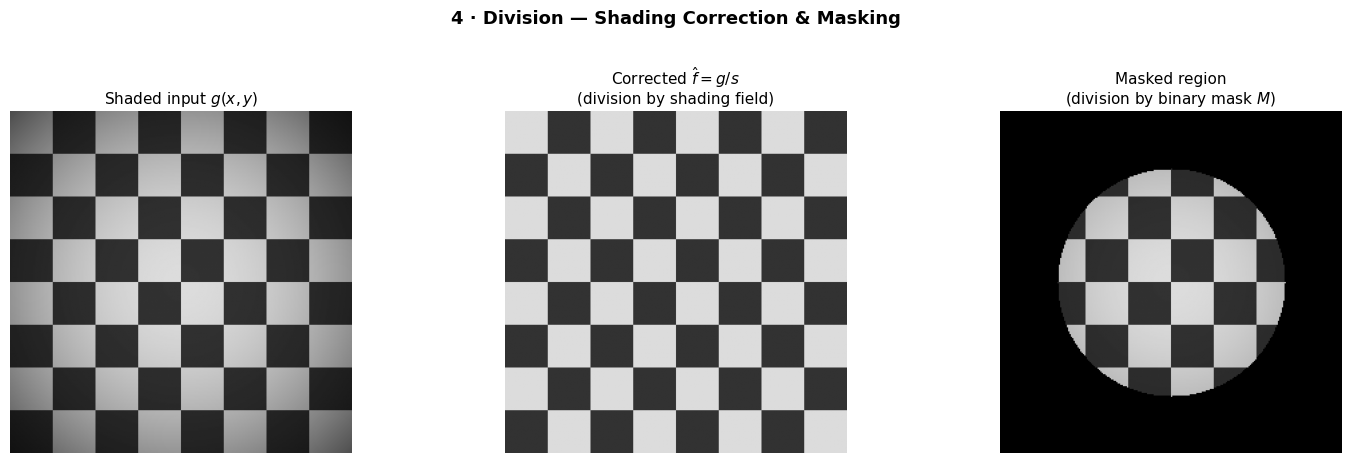

In [10]:
show_row(
    images=[shaded, corrected, masked],
    titles=[
        'Shaded input $g(x,y)$',
        'Corrected $\\hat{f} = g / s$\n(division by shading field)',
        'Masked region\n(division by binary mask $M$)'
    ],
    vmins=[0,0,0], vmaxs=[1,1,1],
    suptitle='4 · Division — Shading Correction & Masking'
)

---
## Summary

| Operation | Formula | Application |
|-----------|---------|-------------|
| **Addition** | $\hat{g} = \frac{1}{k}\sum g_i$ | Noise reduction; $\sigma_{\text{avg}} = \sigma/\sqrt{k}$ |
| **Subtraction** | $d = f - (f\;\mathtt{AND}\;\texttt{0xFE})$ | LSB map, bit-plane analysis |
| **Multiplication** | $g = f \cdot s$ | Simulate non-uniform illumination |
| **Division** | $\hat{f} = g / s$ | Flat-field / shading correction; masking |

> **Key insight:** Division is the inverse of multiplication — if shading degrades an image by multiplication, dividing by the same field perfectly restores it.